# ICT-33 — Ensembles ouverts : soupes, collisions, et la mesure du bruit macro

> **Série** : ICT (Information – Causalité – Topologie), phase narrative de l'issue #5726 — « faire du Jeu de la Vie un *vrai* substrat de stratification ICT ». Prérequis : [ICT-32-StratificationCausaleLife.ipynb](ICT-32-StratificationCausaleLife.ipynb) (la stratification par l'ensemble sur substrat certifié) et [ICT-Life-SubstratCertifie.ipynb](ICT-Life-SubstratCertifie.ipynb) (phase-zero, calibration des patterns canoniques).

[ICT-32](ICT-32-StratificationCausaleLife.ipynb) a mesuré le Jeu de la Vie sur des ensembles **fermés et saturés** : le cycle canonique d'une part (déterminisme 1, aucune macro ne bat le micro), l'ensemble **exhaustif** des graines d'un tore d'autre part — toutes les causes possibles énumérées une fois chacune, TPM aux lignes one-hot. Il reste une troisième famille d'ensembles, celle que rencontrent les expérimentateurs du Game of Life depuis Conway : l'**ensemble ouvert et conditionné**. On ne tire pas toutes les graines ; on tire des grilles **aléatoires de densité donnée** — les fameuses *random soups* — et on regarde ce qu'elles deviennent. Ce notebook mesure ce que cette ouverture change pour la batterie ICT :

1. **L'ensemble conditionné rend la TPM macro *stochastique*.** Sur l'observable la plus naturelle — la population (nombre de cellules vivantes) — deux grilles de même population à t=0 peuvent mener à des populations différentes à t=1. Le témoin négatif d'ICT-32 (la partition population, qui s'effondre sur le tore) devient ici une **grandeur mesurée** : le déterminisme de la TPM empirique tombe bien en dessous de 1, et cette chute *est* le contenu d'information jeté par la projection.
2. **Le banc des collisions fournit le diagnostic micro.** Deux gliders head-on de même masse (10 cellules) aboutissent à l'annihilation, à un glider survivant ou à des débris selon la phase et l'offset exacts de l'impact — le destin dépend finement de détails que l'observable population ne code pas.

Le moteur, lui, reste déterministe — c'est même un théorème : `hashlife_correct` (track `conway_lean`, clos sans `sorry` sur `main`) garantit le calcul des générations. Le bruit que nous allons mesurer n'est donc **pas dans le moteur** : il est dans la projection macro. C'est la distinction que ce notebook veut rendre tangible.


In [1]:
import os, sys
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict.life import (
    random_soup,
    empirical_tpm_live_count,
    torus_ensemble_tpm,
    glider_collision,
    collision_outcome,
    trajectory,
)
from ict.causal_emergence import causal_profile

print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

numpy 2.4.2 | matplotlib 3.10.8


## 1. Le point de départ : l'ensemble saturé (rappel ICT-32)

Sur le tore 2×2, l'ensemble des graines est **exhaustif** : les 16 configurations possibles, chacune une fois. La TPM de cet ensemble est one-hot par construction — chaque cause (graine) a exactement un successeur, garanti par le déterminisme de la règle B3/S23. Le déterminisme vaut donc 1.000 *par définition*, pas par prouesse statistique : l'ensemble énumère chaque cause, et une cause n'a qu'un effet.


In [2]:
tpm2, succ2 = torus_ensemble_tpm(2)
prof2 = causal_profile(tpm2)
print(f"tore 2x2 : {prof2['n']} graines | determinisme {prof2['determinism']:.3f} | "
      f"degenerescence {prof2['degeneracy']:.3f} | effectiveness {prof2['effectiveness']:.3f} | "
      f"EI {prof2['effective_information']:.3f} bits")

tore 2x2 : 16 graines | determinisme 1.000 | degenerescence 0.672 | effectiveness 0.328 | EI 1.311 bits


### Lecture du résultat

Le déterminisme à 1.000 est structurel : chaque ligne de la TPM est un Dirac. Ce qui rend ce régime intéressant pour ICT-32, c'est la **dégénérescence** (des causes différentes convergent vers le même effet — 12 des 16 graines mènent à la grille vide) : c'est elle qu'une macro bien choisie (les strates de destin) peut restaurer. Mais l'ensemble lui-même reste **fermé** : 16 causes, ni plus ni moins, tirées de l'énumération complète. Ouvrons-le.


## 2. L'ensemble ouvert : la soupe conditionnée par sa densité

Une *random soup* est une grille toroïdale où chaque cellule est vivante indépendamment avec probabilité `density` (Bernoulli i.i.d.). L'ensemble n'est plus exhaustif — c'est un **tirage sous une mesure** conditionnée par la densité. C'est le régime de toutes les expériences « soupe » de la littérature Life : on sème au hasard, on regarde ce qui émerge (blinker ponds, gliders qui s'échappent, débris stables).

L'observable macro la plus simple reste la **population** : le nombre de cellules vivantes. La question de ce notebook est exactement celle qu'ICT-32 posait avec le témoin négatif, mais désormais *sur des données* : que vaut le déterminisme de la TPM empirique de cette observable, quand l'ensemble est ouvert ?


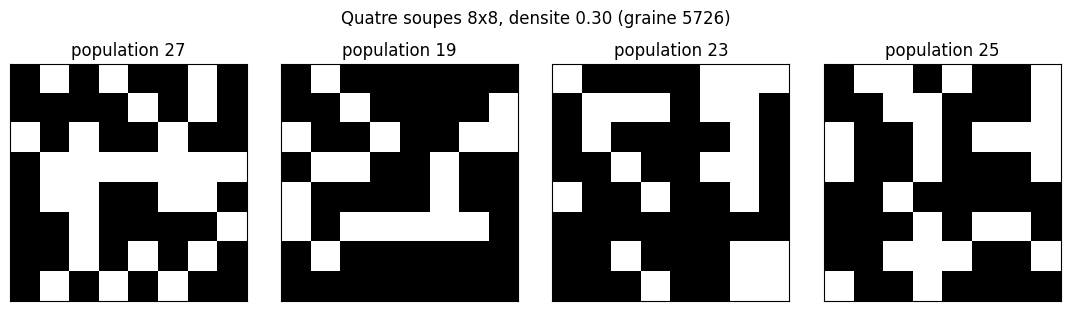

In [3]:
rng = np.random.default_rng(5726)
soups = [random_soup(8, 0.30, rng) for _ in range(4)]

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, soup in zip(axes, soups):
    ax.imshow(soup, cmap="binary_r")
    ax.set_title(f"population {int(soup.sum())}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Quatre soupes 8x8, densite 0.30 (graine 5726)", y=1.02)
plt.tight_layout(); plt.show()

### Lecture du résultat

Quatre grilles, quatre populations, quatre **configurations** différentes pour une même loi de tirage. La densité conditionne la population en moyenne, mais chaque tirage réalise une configuration micro précise — et c'est la configuration (le voisinage de chaque cellule), pas la population, qui détermine le pas suivant. Construisons la TPM empirique de l'observable population et mesurons ce que cette projection jette.


In [4]:
rng = np.random.default_rng(5726)
soups = [random_soup(8, 0.30, rng) for _ in range(4000)]
tpm_soup, axis = empirical_tpm_live_count(soups)

masse = tpm_soup.sum(axis=1)
sources = masse > 0                        # populations observees a t=0
commun = sources & (tpm_soup.sum(axis=0) > 0)     # ...et aussi comme effet
sub = tpm_soup[np.ix_(commun, commun)]
# strates dont le destin sort de l'axe : lignes nulles ; les retirer peut vider
# une colonne (le seul destin d'une autre strate) -> iterer jusqu'a stabilite
while sub.shape[0] > 1 and (sub.sum(axis=1) == 0).any():
    vides = sub.sum(axis=1) == 0
    sub = sub[np.ix_(~vides, ~vides)]
perte = 1.0 - sub.sum() / masse[sources].sum()
sub = sub / sub.sum(axis=1, keepdims=True)
prof_soup = causal_profile(sub)

entropies = np.array([-sum(p * np.log2(p) for p in row if p > 0)
                      for row in tpm_soup[sources]])
nb_stoch = int((entropies > 1e-9).sum())
print(f"axe : {len(axis)} populations | lignes sources : {int(sources.sum())} "
      f"| dont stochastiques : {nb_stoch}")
print(f"sous-TPM valide : {sub.shape[0]} etats retenus sur {len(axis)} dans l'axe, "
      f"masse ecartee : {100*perte:.2f} %")
print(f"determinisme {prof_soup['determinism']:.3f} | degenerescence {prof_soup['degeneracy']:.3f} | "
      f"effectiveness {prof_soup['effectiveness']:.3f} | EI {prof_soup['effective_information']:.3f} bits")

pops_src = np.array(axis)[sources]
mediane = int(pops_src[len(pops_src) // 2])
row = tpm_soup[axis.index(mediane)]
destins = {axis[k]: round(float(row[k]), 3) for k in np.nonzero(row)[0]}
print(f"exemple — strate population {mediane} -> destins {destins}")

axe : 39 populations | lignes sources : 27 | dont stochastiques : 23
sous-TPM valide : 25 etats retenus sur 39 dans l'axe, masse ecartee : 14.86 %
determinisme 0.334 | degenerescence 0.044 | effectiveness 0.290 | EI 1.345 bits
exemple — strate population 20 -> destins {9: 0.002, 13: 0.015, 14: 0.005, 15: 0.007, 16: 0.017, 17: 0.029, 18: 0.041, 19: 0.039, 20: 0.073, 21: 0.051, 22: 0.071, 23: 0.078, 24: 0.093, 25: 0.088, 26: 0.076, 27: 0.063, 28: 0.054, 29: 0.059, 30: 0.039, 31: 0.041, 32: 0.024, 33: 0.015, 34: 0.012, 35: 0.005, 40: 0.002}


### Lecture du résultat — le bruit macro est mesuré, pas décrété

Trois choses sont lisibles dans cette sortie :

1. **La TPM est massivement stochastique.** 23 des 27 strates sources ont plusieurs destins possibles, et la strate médiane (population 20) en compte 25 — de la population 9 à la population 40. À contraster avec les lignes one-hot du tore exhaustif : même règle, même moteur déterministe, mais l'observable projetée ne voit plus un destin certain. Ces comptes sont reproductibles : le tirage est entièrement seedé (graine 5726, 4000 soupes), la « statistique » est ici un recensement déterministe de l'échantillon.
2. **Le déterminisme tombe à un tiers.** Sous cette graine : 0.334, contre 1.000 pour le tore exhaustif. La projection « population » ne transmet qu'un tiers de l'information causale d'un pas de la dynamique — c'est la version *mesurée* du témoin négatif d'ICT-32, et le chiffre mérite le contraste : la dégénérescence, elle, s'effondre (0.044 contre 0.672), car les destins moyens des strates sont presque tous distincts.
3. **Une subtilité de construction, à ne pas cacher :** les populations observées *seulement* à t=1 (jamais comme cause à t=0) ont une ligne nulle par construction. Sur une soupe 8×8 de densité 0.30, le premier pas fait *chuter* la population moyenne — la queue basse de la distribution t+1 s'étend sous le support de t=0, si bien qu'une part de la masse (ici 14.9 %) tombe sur des états jamais observés comme causes. Pour que `causal_profile` valide une matrice carrée à lignes sommant à 1, on retire les lignes fuyantes (jusqu'à stabilité : retirer une ligne peut vider la colonne qui était le seul destin d'une autre) et on renormalise. La masse écartée par cette mise au carré est **mesurée et affichée** — à ce niveau, elle se déclare et s'interprète (effet de bord de la grille finie), elle ne se tait pas.

Le point conceptuel : le bruit de cette TPM n'est **pas un bruit du moteur**. Il vient de ce que deux états micro distincts (configurations différentes) partagent le même état macro (population) — le destin de la *configuration* est certain, celui de la *population* ne l'est pas. La section suivante le démontre sur un banc où l'on contrôle le micro à la main.


## 3. Le banc discriminant : la batterie de collisions

Pour voir à l'œil nu ce que la projection jette, rien ne vaut la collision de deux gliders. `glider_collision(phase, offset)` pose deux gliders head-on sur une grille 32×32 : le premier (cap sud-est) en haut à gauche, le second (rotation de 180°, cap nord-ouest) avancé de `phase` pas dans son propre cycle puis placé avec un décalage de `offset` colonnes. Les deux configurations ci-dessous ont **exactement la même masse** — 10 cellules — et le même moteur déterministe. Leurs destins divergent complètement.


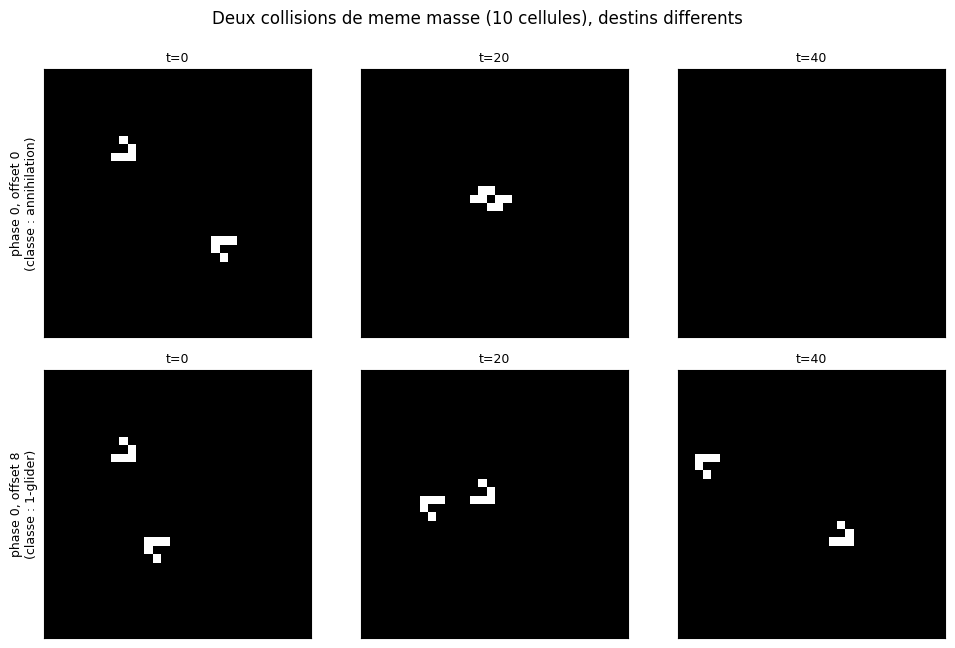

In [5]:
configurations = [(0, 0, "annihilation"), (0, 8, "1-glider survivant")]
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for i, (phase, offset, attendu) in enumerate(configurations):
    grille = glider_collision(phase=phase, offset=offset)
    film = trajectory(grille, 40)
    for j, step in enumerate([0, 20, 40]):
        axes[i, j].imshow(film[step], cmap="binary_r")
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, j].set_title(f"t={step}", fontsize=9)
    verdict = collision_outcome(grille)
    axes[i, 0].set_ylabel(f"phase {phase}, offset {offset}\n(classe : {verdict['class']})",
                          fontsize=9)
fig.suptitle("Deux collisions de meme masse (10 cellules), destins differents", y=0.99)
plt.tight_layout(); plt.show()

### Lecture du résultat

Deux grilles de 10 cellules vivantes. L'une s'annihile proprement, l'autre laisse repartir un glider. Au niveau micro, tout est joué dans les premières générations — l'onde de collision détruit ou reconstruit exactement les cellules qu'il faut selon l'alignement initial. Balisons systématiquement ce paramétrage : 4 phases × 12 offsets = 48 collisions, chacune classée par `collision_outcome` (annihilation totale, un glider survivant, ou débris).


In [6]:
destins = {}
for phase in range(4):
    for offset in range(-3, 9):
        cls = collision_outcome(glider_collision(phase=phase, offset=offset))["class"]
        destins[(phase, offset)] = cls

compteur = Counter(destins.values())
print("batterie 4 phases x 12 offsets (48 collisions) :", dict(compteur))

sigle = {"annihilation": "A", "1-glider": "G", "2-gliders": "M", "debris": "D"}
print()
print("A = annihilation | G = 1-glider | D = debris")
print("phase\\offset " + " ".join(f"{off:+d}".rjust(3) for off in range(-3, 9)))
for phase in range(4):
    print(f"   phase {phase}   " + " ".join(sigle[destins[(phase, off)]].rjust(3)
                                            for off in range(-3, 9)))

batterie 4 phases x 12 offsets (48 collisions) : {'annihilation': 21, '1-glider': 7, 'debris': 20}

A = annihilation | G = 1-glider | D = debris
phase\offset  -3  -2  -1  +0  +1  +2  +3  +4  +5  +6  +7  +8
   phase 0     A   A   A   A   A   A   A   A   A   A   A   G
   phase 1     D   A   D   A   D   A   D   D   D   D   G   G
   phase 2     D   D   D   A   D   D   D   D   G   D   G   G
   phase 3     D   D   A   A   A   A   A   D   D   D   A   G


### Lecture du résultat — le destin dépend de détails que la masse ne code pas

La batterie dit trois choses :

1. **Trois classes de destin pour une même masse initiale** (10 cellules partout) : 21 annihilations, 7 collisions laissant un glider survivant, 20 débris — et **aucune** collision ratée (jamais deux gliders ne se croisent sans interagir : head-on, l'interaction est certaine).
2. **La table en damier montre la sensibilité fine** : à phase fixée, décaler l'impact d'une seule colonne change la classe du destin. La frontière entre annihilation et débris n'est pas une gradation — c'est une bascule.
3. **Aucune observable macro grossière ne sépare ces cas.** Population : 10 partout. Même le nombre de composantes connexes initial (2) est identique. Ce qui sépare l'annihilation du glider survivant, c'est l'alignement *relatif* des deux motifs — quelques bits de configuration micro.

C'est exactement l'information que la TPM « population » de la section 2 mélange dans ses lignes stochastiques : des états micro au destin certain, projetés sur le même état macro, y deviennent une distribution de destins.


## 4. Le contraste des profils causaux

Réunissons les deux régimes dans le vocabulaire de la batterie ICT. Les deux TPM n'ont pas la même origine — l'une est énumérée (exhaustive, one-hot), l'autre estimée (tirage sous mesure, stochastique) — mais elles portent le même nomenclateur : déterminisme, dégénérescence, effectiveness, information effective. Les axes sont de tailles comparables, les grandeurs se comparent donc directement.


regime                                   n     det     deg     eff  EI (bits)
micro tore 2x2 (exhaustif, one-hot)     16   1.000   0.672   0.328      1.311
macro population (soupe, empirique)     25   0.334   0.044   0.290      1.345


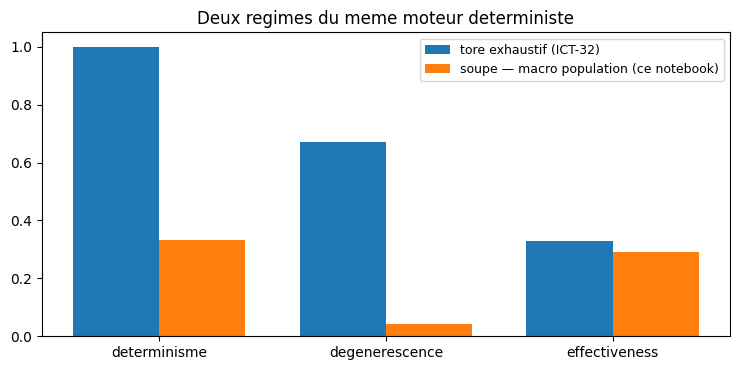

In [7]:
lignes = [("micro tore 2x2 (exhaustif, one-hot)", prof2),
          ("macro population (soupe, empirique)", prof_soup)]
print(f"{'regime':<38}{'n':>4}{'det':>8}{'deg':>8}{'eff':>8}{'EI (bits)':>11}")
for nom, p in lignes:
    print(f"{nom:<38}{p['n']:>4}{p['determinism']:>8.3f}{p['degeneracy']:>8.3f}"
          f"{p['effectiveness']:>8.3f}{p['effective_information']:>11.3f}")

etiquettes = ["determinisme", "degenerescence", "effectiveness"]
x = np.arange(len(etiquettes)); l = 0.38
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(x - l/2, [prof2["determinism"], prof2["degeneracy"], prof2["effectiveness"]],
       l, label="tore exhaustif (ICT-32)")
ax.bar(x + l/2, [prof_soup["determinism"], prof_soup["degeneracy"], prof_soup["effectiveness"]],
       l, label="soupe — macro population (ce notebook)")
ax.set_xticks(x); ax.set_xticklabels(etiquettes)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
ax.set_title("Deux regimes du meme moteur deterministe")
plt.tight_layout(); plt.show()

### Lecture du résultat — le bruit n'est pas dans le moteur, il est dans la projection

La colonne déterminisme résume le notebook : le **même moteur** — déterministe, et certifié tel par `hashlife_correct` (`conway_lean`, clos sans `sorry` sur `main`) — présente un déterminisme de 1.000 sur l'ensemble énuméré et une valeur très inférieure sur la TPM empirique de l'observable population. Aucune stochasticité n'a été ajoutée à la règle ; seule la **description** a changé. En vocabulaire Hoel : la projection « population » est une *perte* d'information causale, mesurée ici directement par la chute du déterminisme.

La suite logique — celle qu'ICT-32 a menée sur l'ensemble fermé — serait de chercher si une **meilleure macro** de l'ensemble ouvert restaure de l'effectiveness : partitionner les soupes non par population mais par des observables plus riches (blocs stables, gliders émis, activité résiduelle). La batterie de collisions donne la borne supérieure de ce qui est récupérable : au niveau micro, chaque configuration a un destin certain — toute l'information est là, il « suffit » de trouver la observable qui la code. C'est la question ouverte que ce notebook laisse, avec les instruments pour l'attaquer.


## Exercice 1 — une autre densité

La TPM empirique dépend de la mesure de tirage. Refaites la mesure de la section 2 à la densité 0.45 (le régime haut, où les soupes surpeuplées s'effondrent massivement) et comparez le déterminisme obtenu à celui de la densité 0.30. Hypothèse à tester : une dynamique d'effondrement massif est-elle *plus* prévisible en population (la plupart des strates convergent vers des populations basses) ou moins ?


In [8]:
def determinisme_soup_densite(density, n=4000):
    """Renvoie le determinisme de la TPM empirique (soupes 8x8) a la densite demandee."""
    # Etape 1 : rng = np.random.default_rng(1) ; construire n soupes random_soup(8, density, rng)
    # Etape 2 : empirical_tpm_live_count, puis retirer les lignes nulles jusqu'a stabilite
    #           (cf section 2) et renormaliser les lignes gardees
    # Indice : validate_tpm exige une matrice carree a lignes sommant a 1
    # Etape 3 : renvoyer causal_profile(sub)['determinism'] et comparer a la densite 0.30
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Exercice 2 — sensibilité à l'offset

Le damier de la section 3 suggère que les classes de destin ne sont pas réparties au hasard le long de l'offset. Mesurez le **plus long palier** : à phase fixée, la plus longue suite d'offsets consécutifs de même classe. Un palier long signale une zone robuste (le destin ne dépend alors que grossièrement de l'impact) ; une alternance courte signale la bascule fine.


In [9]:
def plus_long_palier(phase):
    """Renvoie (longueur, classe, liste des offsets) du plus long palier a phase donnee."""
    # Etape 1 : destins = [collision_outcome(glider_collision(phase=phase, offset=off))["class"]
    #            for off in range(-3, 9)]
    # Etape 2 : balayer les offsets consecutifs et mesurer les paliers de classe identique
    # Etape 3 : renvoyer le plus long (longueur, classe, offsets) et comparer phase 0 vs phase 3
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Exercice 3 — la strate la plus déterministe

Le déterminisme de la TPM empirique est une *moyenne* d'entropies de lignes. Certaines strates sont presque des Dirac : les populations très basses (grille quasi vide) ont un destin quasi certain en population — l'extinction ou le quasi-statut. Retrouvez laquelle, et situez-la : la stochasticité mesurée en section 2 est-elle uniformément répartie, ou concentrée dans les strates moyennes ?


In [10]:
def strate_la_plus_deterministe():
    """Renvoie la population de la strate source d'entropie minimale (destin le plus certain)."""
    # Etape 1 : recalculer tpm_soup, axis (meme recette : graine 5726, 4000 soupes densite 0.30)
    # Etape 2 : entropie de chaque ligne source (convention 0*log2(0) = 0)
    # Etape 3 : renvoyer la population d'entropie minimale et commenter sa position
    #           dans l'axe (basse / moyenne population)
    pass  # TODO etudiant
    return None  # TODO etudiant

print("Exercice a completer")

Exercice a completer


## Conclusion

ICT-33 complète la triade des ensembles du substrat Life : **fermé-saturé** (le cycle canonique d'ICT-32), **fermé-exhaustif** (le tore de ICT-32), et désormais **ouvert-conditionné** (la soupe de ce notebook). Le résultat central tient en une phrase : sur un moteur déterministe certifié (`hashlife_correct`), l'ouverture de l'ensemble ne crée pas de bruit — la **projection** en crée. La TPM empirique de l'observable population est stochastique parce que des configurations micro au destin certain partagent le même état macro, et la batterie de collisions en est la démonstration contrôlée : même masse, même moteur, trois classes de destin qui basculent au décalage d'une colonne.

Instruments posés dans `ict/life.py` : `random_soup`, `empirical_tpm_live_count`, `glider_collision`, `collision_outcome` (avec `connected_components`, `is_glider`). Suite naturelle : la recherche d'une macro qui code le destin sur l'ensemble ouvert — la partition de l'espace des soupes par observables d'émergence (gliders émis, blocs stables formés), dont l'effectiveness restaurée mesurerait exactement l'information causale que la population jette.